# Attention Pattern Analysis — GPT-OSS Prompt Injection

Fine-grained layer × head attention analysis at the first reasoning token.
Stratified by example (payload × task), perturbation N, and success/failure.

## Examples in this dataset
| Example key | Suite | User task | Inj task | Character |
|---|---|---|---|---|
| `banking` | banking | user_task_8 | injection_task_7 | hard — almost always fails even at N=1 |
| `slack`   | slack   | user_task_0 | injection_task_4 | easy — mostly succeeds at low N |
| `travel`  | travel  | user_task_2 | injection_task_6 | sparse data (N≤8 only) |

## Architecture notes (GPT-OSS 20B)
- 24 layers, 64 heads
- **Even layers (0,2,…,22) = LOCAL** — sliding-window (~256 tokens)
- **Odd layers (1,3,…,23) = GLOBAL** — full-context
- The payload always lands within the local window (right before reasoning tokens), so **all layers can attend to it**
- **Attention sink at position 0** — strong in layers 7 and 9; tracked separately and excluded from all other group masks

In [7]:
import pickle, sqlite3, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

sns.set_theme(style='whitegrid', font_scale=0.9)

# ── Paths ──────────────────────────────────────────────────────────────────
LOG_DIR     = Path('profiling_logs_v6')
DB_PATH     = LOG_DIR / 'experiment_logs.db'
TENSOR_BASE = Path('.')   # cap_paths stored as 'profiling_logs_v3/tensors/<id>_cap.pt'

# ── Architecture ───────────────────────────────────────────────────────────
N_LAYERS      = 24
N_HEADS       = 64
LOCAL_LAYERS  = set(range(0, N_LAYERS, 2))   # sliding-window
GLOBAL_LAYERS = set(range(1, N_LAYERS, 2))   # full-context
ALL_LAYERS    = list(range(N_LAYERS))
SINK_POSITIONS = {0}   # excluded from all span-group masks; tracked separately

# x-tick labels: layer index + L/G
LAYER_LABELS = [f'{i}\n{"L" if i in LOCAL_LAYERS else "G"}' for i in ALL_LAYERS]

# ── Span groups ────────────────────────────────────────────────────────────
SPAN_GROUPS = {
    'payload':    {'attack_payload', 'attack_prefix', 'attack_suffix'},
    'user':       {'user_instruction'},
    'system':     {'system_meta', 'developer_instructions', 'developer_tools'},
    'tool_clean': {'tool_env_data'},
    'frame':      {'frame_boundary', 'frame_message', 'frame_role',
                   'frame_channel', 'frame_channel_name',
                   'frame_constrain', 'frame_constrain_type', 'frame_metadata'},
}
ALL_GROUPS  = list(SPAN_GROUPS.keys()) + ['sink']
GROUP_COLOR = {
    'payload': '#e74c3c', 'user': '#3498db', 'system': '#9b59b6',
    'tool_clean': '#f39c12', 'frame': '#95a5a6', 'sink': '#1abc9c',
}

print('Config ready.')

Config ready.


In [8]:
# ── Load everything from SQLite ─────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

cur.execute("SELECT metadata_json FROM logs WHERE event='profiling_run'")
runs_meta = {json.loads(r[0])['run_id']: json.loads(r[0]) for r in cur.fetchall()}

cur.execute("SELECT metadata_json, object_data FROM logs WHERE event='profiling_capture'")
cap_by_run = {}
for meta_json, obj_data in cur.fetchall():
    rid = json.loads(meta_json)['run_id']
    cap_by_run[rid] = pickle.loads(obj_data)

conn.close()
print(f'Runs: {len(runs_meta)}   Captures: {len(cap_by_run)}')

Runs: 16   Captures: 16


In [9]:
# ── Build example index ─────────────────────────────────────────────────────
#
# EXAMPLES[key] = {
#   'parent_run_id', 'suite', 'user_task_id', 'injection_task_id', 'runs'
# }
# key = short label: 'banking', 'slack', 'travel'

EXAMPLES = {}
for rid, meta in runs_meta.items():
    if meta.get('source') != 'baseline':
        continue
    key = meta['suite'].split('_')[0]
    EXAMPLES[key] = {
        'parent_run_id':     rid,
        'suite':             meta['suite'],
        'user_task_id':      meta['user_task_id'],
        'injection_task_id': meta.get('injection_task_id'),
        'runs': [],
    }

for rid, meta in runs_meta.items():
    if meta.get('source') != 'perturbation':
        continue
    pid = meta.get('parent_run_id')
    for ex in EXAMPLES.values():
        if ex['parent_run_id'] == pid:
            ex['runs'].append(meta)
            break

# ── Summary: runs and capture coverage per example × N ─────────────────────
rows = []
for key, ex in EXAMPLES.items():
    counts = {}
    for r in ex['runs']:
        N = r.get('perturbation_N')
        if N not in counts:
            counts[N] = {'runs': 0, 'succ': 0, 'fail': 0, 'cap': 0, 'cap_succ': 0, 'cap_fail': 0}
        counts[N]['runs'] += 1
        if r.get('success'): counts[N]['succ'] += 1
        else:                counts[N]['fail'] += 1
        if r['run_id'] in cap_by_run:
            counts[N]['cap'] += 1
            if r.get('success'): counts[N]['cap_succ'] += 1
            else:                counts[N]['cap_fail'] += 1
    for N, c in sorted(counts.items(), key=lambda x: (x[0] is None, x[0])):
        rows.append({'example': key, 'N': int(N),
                     'runs': c['runs'], 'captures': c['cap'],
                     'cap_succ': c['cap_succ'], 'cap_fail': c['cap_fail']})

df_index = pd.DataFrame(rows)
print(df_index.to_string(index=False))
print()
print('NOTE: only examples with cap_succ > 0 AND cap_fail > 0 can produce Δ heatmaps.')

example  N  runs  captures  cap_succ  cap_fail
banking  1    15        15         8         7

NOTE: only examples with cap_succ > 0 AND cap_fail > 0 can produce Δ heatmaps.


In [31]:
# ── Core analysis helpers ───────────────────────────────────────────────────

def _span_mask(spans, seq_len, tag_set, exclude=None):
    m = torch.zeros(seq_len, dtype=torch.bool)
    for s in spans:
        if s['tag'] in tag_set:
            m[s['start']:min(s['end'], seq_len)] = True
    if exclude:
        for p in exclude:
            if p < seq_len: m[p] = False
    return m


def _attn_mass(cap, mask):
    """
    Returns (N_LAYERS, N_HEADS) of attention mass to masked positions
    at the first reasoning token.  NaN for missing layers.
    """
    out = np.full((N_LAYERS, N_HEADS), np.nan)
    for li in ALL_LAYERS:
        if li not in cap['attention']:
            continue
        a  = cap['attention'][li]       # (heads, n_pos, klen)
        a0 = a[:, 0, :].float()         # first reasoning token, all heads
        m  = mask[:a0.shape[-1]].float()
        out[li] = (a0 * m.unsqueeze(0)).sum(-1).numpy()
    return out


def load_matrices(run_ids, group):
    """
    Load attention mass for a list of runs.
    Returns np.array (n_runs, N_LAYERS, N_HEADS), or None.
    Runs with missing tensors are silently skipped.

    group: 'payload' | 'user' | 'system' | 'tool_clean' | 'frame' | 'sink'
    Sink positions are excluded from all non-sink group masks.
    """
    mats = []
    for rid in run_ids:
        ci = cap_by_run.get(rid)
        if ci is None: continue
        path = TENSOR_BASE / ci['cap_path']
        if not path.exists(): continue
        cap     = torch.load(path, map_location='cpu', weights_only=False)
        seq_len = cap['seq_len']
        if group == 'sink':
            mask = _span_mask([], seq_len, set())
            for p in SINK_POSITIONS:
                if p < seq_len: mask[p] = True
        else:
            mask = _span_mask(ci['spans'], seq_len, SPAN_GROUPS[group], SINK_POSITIONS)
        mats.append(_attn_mass(cap, mask))
    return np.stack(mats, axis=0) if mats else None


def get_run_ids(example_key, N, success=None):
    """Run IDs for a given example and N, optionally filtered by success."""
    return [
        r['run_id'] for r in EXAMPLES[example_key]['runs']
        if r.get('perturbation_N') == N
        and (success is None or bool(r.get('success')) == success)
    ]


def build_matrices(example_key, N, groups=None):
    """
    Build success/failure attention matrices for one (example, N) pair.

    Returns dict:
      group -> {
        'succ':      (n_succ, L, H),
        'fail':      (n_fail, L, H),
        'succ_mean': (L, H),
        'fail_mean': (L, H),
        'diff':      (L, H)   # succ_mean - fail_mean
        'n_succ': int, 'n_fail': int,
      }
    """
    if groups is None:
        groups = ALL_GROUPS
    succ_ids = get_run_ids(example_key, N, success=True)
    fail_ids = get_run_ids(example_key, N, success=False)
    result = {}
    for grp in groups:
        s  = load_matrices(succ_ids, grp)
        f  = load_matrices(fail_ids, grp)
        sm = np.nanmean(s, axis=0) if s is not None else None
        fm = np.nanmean(f, axis=0) if f is not None else None
        result[grp] = {
            'succ': s, 'fail': f,
            'succ_mean': sm, 'fail_mean': fm,
            'diff': (sm - fm) if (sm is not None and fm is not None) else None,
            'n_succ': len(succ_ids), 'n_fail': len(fail_ids),
        }
    return result


print('Helpers ready: load_matrices / get_run_ids / build_matrices')

Helpers ready: load_matrices / get_run_ids / build_matrices


In [32]:
# ── Plot functions ──────────────────────────────────────────────────────────

def _xticks(ax, step=4):
    ticks = list(range(0, N_LAYERS, step))
    ax.set_xticks(ticks)
    ax.set_xticklabels([LAYER_LABELS[i] for i in ticks], fontsize=7)
    for li in LOCAL_LAYERS:
        ax.axvline(li - 0.5, color='steelblue', linewidth=0.25, alpha=0.35)


def plot_layerhead(mats, group='payload', title='', save=None):
    """
    3-panel Layer×Head heatmap for one span group:
      success mean  |  failure mean  |  Δ (success − failure)
    """
    d = mats[group]
    if d['diff'] is None:
        print(f'  {group}: insufficient data (succ={d["n_succ"]} fail={d["n_fail"]})'); return
    sm, fm, diff = d['succ_mean'], d['fail_mean'], d['diff']
    n_s, n_f = d['n_succ'], d['n_fail']
    vmax_d = np.nanmax(np.abs(diff))

    fig, axes = plt.subplots(1, 3, figsize=(20, 9))
    for ax, mat, cmap, vmin, vmax, panel in zip(
        axes,
        [sm.T,   fm.T,   diff.T],
        ['YlOrRd', 'YlOrRd', 'RdYlGn'],
        [0,        0,       -vmax_d],
        [np.nanmax(sm), np.nanmax(fm), vmax_d],
        [f'Success (n={n_s})', f'Failure (n={n_f})', 'Δ = Success − Failure'],
    ):
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                       interpolation='nearest', origin='lower')
        ax.set_xlabel('Layer  (L=local  G=global)', fontsize=9)
        ax.set_ylabel('Head', fontsize=9)
        ax.set_title(panel, fontsize=10)
        _xticks(ax)
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

    fig.suptitle(f'{title}  |  {group}', fontsize=12)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_layerhead_all_groups(mats, title='', save=None):
    """
    Grid overview: one row per span group, 3 cols (success | failure | Δ).
    """
    groups = [g for g in ALL_GROUPS if mats[g]['diff'] is not None]
    fig, axes = plt.subplots(len(groups), 3,
                              figsize=(20, 3.5 * len(groups)), squeeze=False)
    for row, grp in enumerate(groups):
        d = mats[grp]
        sm, fm, diff = d['succ_mean'], d['fail_mean'], d['diff']
        n_s, n_f = d['n_succ'], d['n_fail']
        vmax_d = np.nanmax(np.abs(diff))
        for col, (mat, cmap, vmin, vmax, panel) in enumerate([
            (sm.T,   'YlOrRd',  0,       np.nanmax(sm),  f'{grp}  success (n={n_s})'),
            (fm.T,   'YlOrRd',  0,       np.nanmax(fm),  f'{grp}  failure (n={n_f})'),
            (diff.T, 'RdYlGn', -vmax_d,  vmax_d,         f'{grp}  Δ'),
        ]):
            ax = axes[row][col]
            im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                           interpolation='nearest', origin='lower')
            ax.set_title(panel, fontsize=9)
            ax.set_ylabel('Head', fontsize=8)
            _xticks(ax)
            if row == len(groups) - 1:
                ax.set_xlabel('Layer  (L=local  G=global)', fontsize=8)
            plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)

    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_violin_by_layer(mats, group='payload', title='', save=None):
    """
    24 subplots (one per layer): per-head attention mass distribution,
    success (green) vs failure (red).  Shows spread, not just the mean.
    """
    d = mats[group]
    succ_arr, fail_arr = d['succ'], d['fail']
    n_s, n_f = d['n_succ'], d['n_fail']

    ncols = 6
    nrows = int(np.ceil(N_LAYERS / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3), squeeze=False)

    for li in ALL_LAYERS:
        ax = axes[li // ncols][li % ncols]
        sv = succ_arr[:, li, :].ravel() if succ_arr is not None else np.array([])
        fv = fail_arr[:, li, :].ravel() if fail_arr is not None else np.array([])
        sv, fv = sv[~np.isnan(sv)], fv[~np.isnan(fv)]

        data = [d for d in [fv, sv] if len(d)]
        pos  = [i for i, d in enumerate([fv, sv]) if len(d)]
        if data:
            parts = ax.violinplot(data, positions=pos, showmedians=True, showextrema=False)
            for pc, c in zip(parts['bodies'], [['#e74c3c','#2ecc71'][p] for p in pos]):
                pc.set_facecolor(c); pc.set_alpha(0.7)
            parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.5)

        ax.set_title(f'Layer {li} ({"L" if li in LOCAL_LAYERS else "G"})', fontsize=8)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'Fail\nn={n_f}', f'Pass\nn={n_s}'], fontsize=6)
        ax.set_ylabel(group, fontsize=7)
        ax.tick_params(axis='y', labelsize=6)

    for idx in range(N_LAYERS, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f'{title}  |  per-layer {group} attn (per-head distribution)', fontsize=11)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_budget(mats, title='', save=None):
    """
    Stacked bar per layer: attention budget across all span groups.
    Solid = success, faded = failure.  Head-averaged per layer.
    """
    x, w = np.arange(N_LAYERS), 0.38
    fig, ax = plt.subplots(figsize=(22, 5))
    bs, bf = np.zeros(N_LAYERS), np.zeros(N_LAYERS)
    for grp in ALL_GROUPS:
        d = mats[grp]
        if d['succ_mean'] is None or d['fail_mean'] is None: continue
        sv = d['succ_mean'].mean(axis=-1)   # (L,)
        fv = d['fail_mean'].mean(axis=-1)
        c  = GROUP_COLOR[grp]
        ax.bar(x - w/2, sv, width=w, bottom=bs, color=c, label=grp, alpha=0.85)
        ax.bar(x + w/2, fv, width=w, bottom=bf, color=c,              alpha=0.45)
        bs += sv; bf += fv

    for li in ALL_LAYERS:
        ax.text(li, -0.007, 'L' if li in LOCAL_LAYERS else 'G',
                ha='center', va='top', fontsize=6, color='steelblue')
    n_s = mats[ALL_GROUPS[0]]['n_succ']
    n_f = mats[ALL_GROUPS[0]]['n_fail']
    ax.set_xticks(x); ax.set_xticklabels([str(i) for i in ALL_LAYERS], fontsize=7)
    ax.set_xlabel('Layer  (L/G shown below)', fontsize=9, labelpad=14)
    ax.set_ylabel('Mean attn mass (head-avg)', fontsize=9)
    ax.set_title(f'{title}  |  attention budget  '
                 f'[solid=success n={n_s},  faded=failure n={n_f}]', fontsize=11)
    ax.legend(title='Span group', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_N_comparison(example_key, N_values=None, group='payload', save=None):
    """
    Δ heatmap (success−failure) side-by-side across N values for one example.
    Shared colour scale across panels so magnitudes are comparable.
    """
    ex = EXAMPLES[example_key]
    if N_values is None:
        N_values = sorted(set(int(r['perturbation_N']) for r in ex['runs']
                              if r['perturbation_N'] is not None))

    # Pre-load all matrices to compute shared vmax
    all_mats = {N: build_matrices(example_key, N, groups=[group]) for N in N_values}
    diffs    = [all_mats[N][group]['diff'] for N in N_values]
    vmax     = max((np.nanmax(np.abs(d)) for d in diffs if d is not None), default=1)

    fig, axes = plt.subplots(1, len(N_values),
                              figsize=(6 * len(N_values), 9), squeeze=False)
    for ax, N in zip(axes[0], N_values):
        d    = all_mats[N][group]
        diff = d['diff']
        if diff is None:
            ax.set_title(f'N={N}\n(no data)'); ax.axis('off'); continue
        im = ax.imshow(diff.T, aspect='auto', cmap='RdYlGn',
                       vmin=-vmax, vmax=vmax,
                       interpolation='nearest', origin='lower')
        ax.set_title(f'N={N}  (succ={d["n_succ"]} fail={d["n_fail"]})', fontsize=9)
        ax.set_xlabel('Layer', fontsize=8)
        ax.set_ylabel('Head', fontsize=8)
        _xticks(ax)
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

    fig.suptitle(f'{example_key}  |  Δ {group} attn (success−failure) — shared colour scale',
                 fontsize=12)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_cross_example(N, group='payload', save=None):
    """
    Side-by-side Δ heatmaps for all examples at the same N.
    Shared colour scale — shows whether the same heads fire across examples.
    """
    examples = [k for k in EXAMPLES
                if any(r['perturbation_N'] == N for r in EXAMPLES[k]['runs'])]
    all_mats = {k: build_matrices(k, N, groups=[group]) for k in examples}
    diffs    = [all_mats[k][group]['diff'] for k in examples]
    vmax     = max((np.nanmax(np.abs(d)) for d in diffs if d is not None), default=1)

    fig, axes = plt.subplots(1, len(examples),
                              figsize=(7 * len(examples), 9), squeeze=False)
    for ax, key in zip(axes[0], examples):
        d    = all_mats[key][group]
        diff = d['diff']
        if diff is None:
            ax.set_title(f'{key}\n(no data)'); ax.axis('off'); continue
        im = ax.imshow(diff.T, aspect='auto', cmap='RdYlGn',
                       vmin=-vmax, vmax=vmax,
                       interpolation='nearest', origin='lower')
        ax.set_title(f'{key}  (succ={d["n_succ"]} fail={d["n_fail"]})', fontsize=10)
        ax.set_xlabel('Layer  (L=local  G=global)', fontsize=9)
        ax.set_ylabel('Head', fontsize=9)
        _xticks(ax)
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

    fig.suptitle(f'Δ {group} attn (success−failure)  N={N}  — shared colour scale', fontsize=12)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


print('Plot functions ready:')
print('  plot_layerhead(mats, group, title)')
print('  plot_layerhead_all_groups(mats, title)')
print('  plot_violin_by_layer(mats, group, title)')
print('  plot_budget(mats, title)')
print('  plot_N_comparison(example_key, N_values, group)')
print('  plot_cross_example(N, group)')

Plot functions ready:
  plot_layerhead(mats, group, title)
  plot_layerhead_all_groups(mats, title)
  plot_violin_by_layer(mats, group, title)
  plot_budget(mats, title)
  plot_N_comparison(example_key, N_values, group)
  plot_cross_example(N, group)


---
## Analysis

### Call pattern
```python
# Build once for a given (example, N), reuse for multiple plots
mats = build_matrices('slack', N=1)

plot_layerhead(mats, group='payload', title='slack N=1')         # single group, 3-panel
plot_layerhead_all_groups(mats, title='slack N=1')               # all groups, grid
plot_violin_by_layer(mats, group='payload', title='slack N=1')   # per-layer distribution
plot_budget(mats, title='slack N=1')                             # attention budget

# Sweep over N for one example
plot_N_comparison('slack', N_values=[1, 8, 32, 64], group='payload')

# Compare examples at a fixed N
plot_cross_example(N=1, group='payload')
```

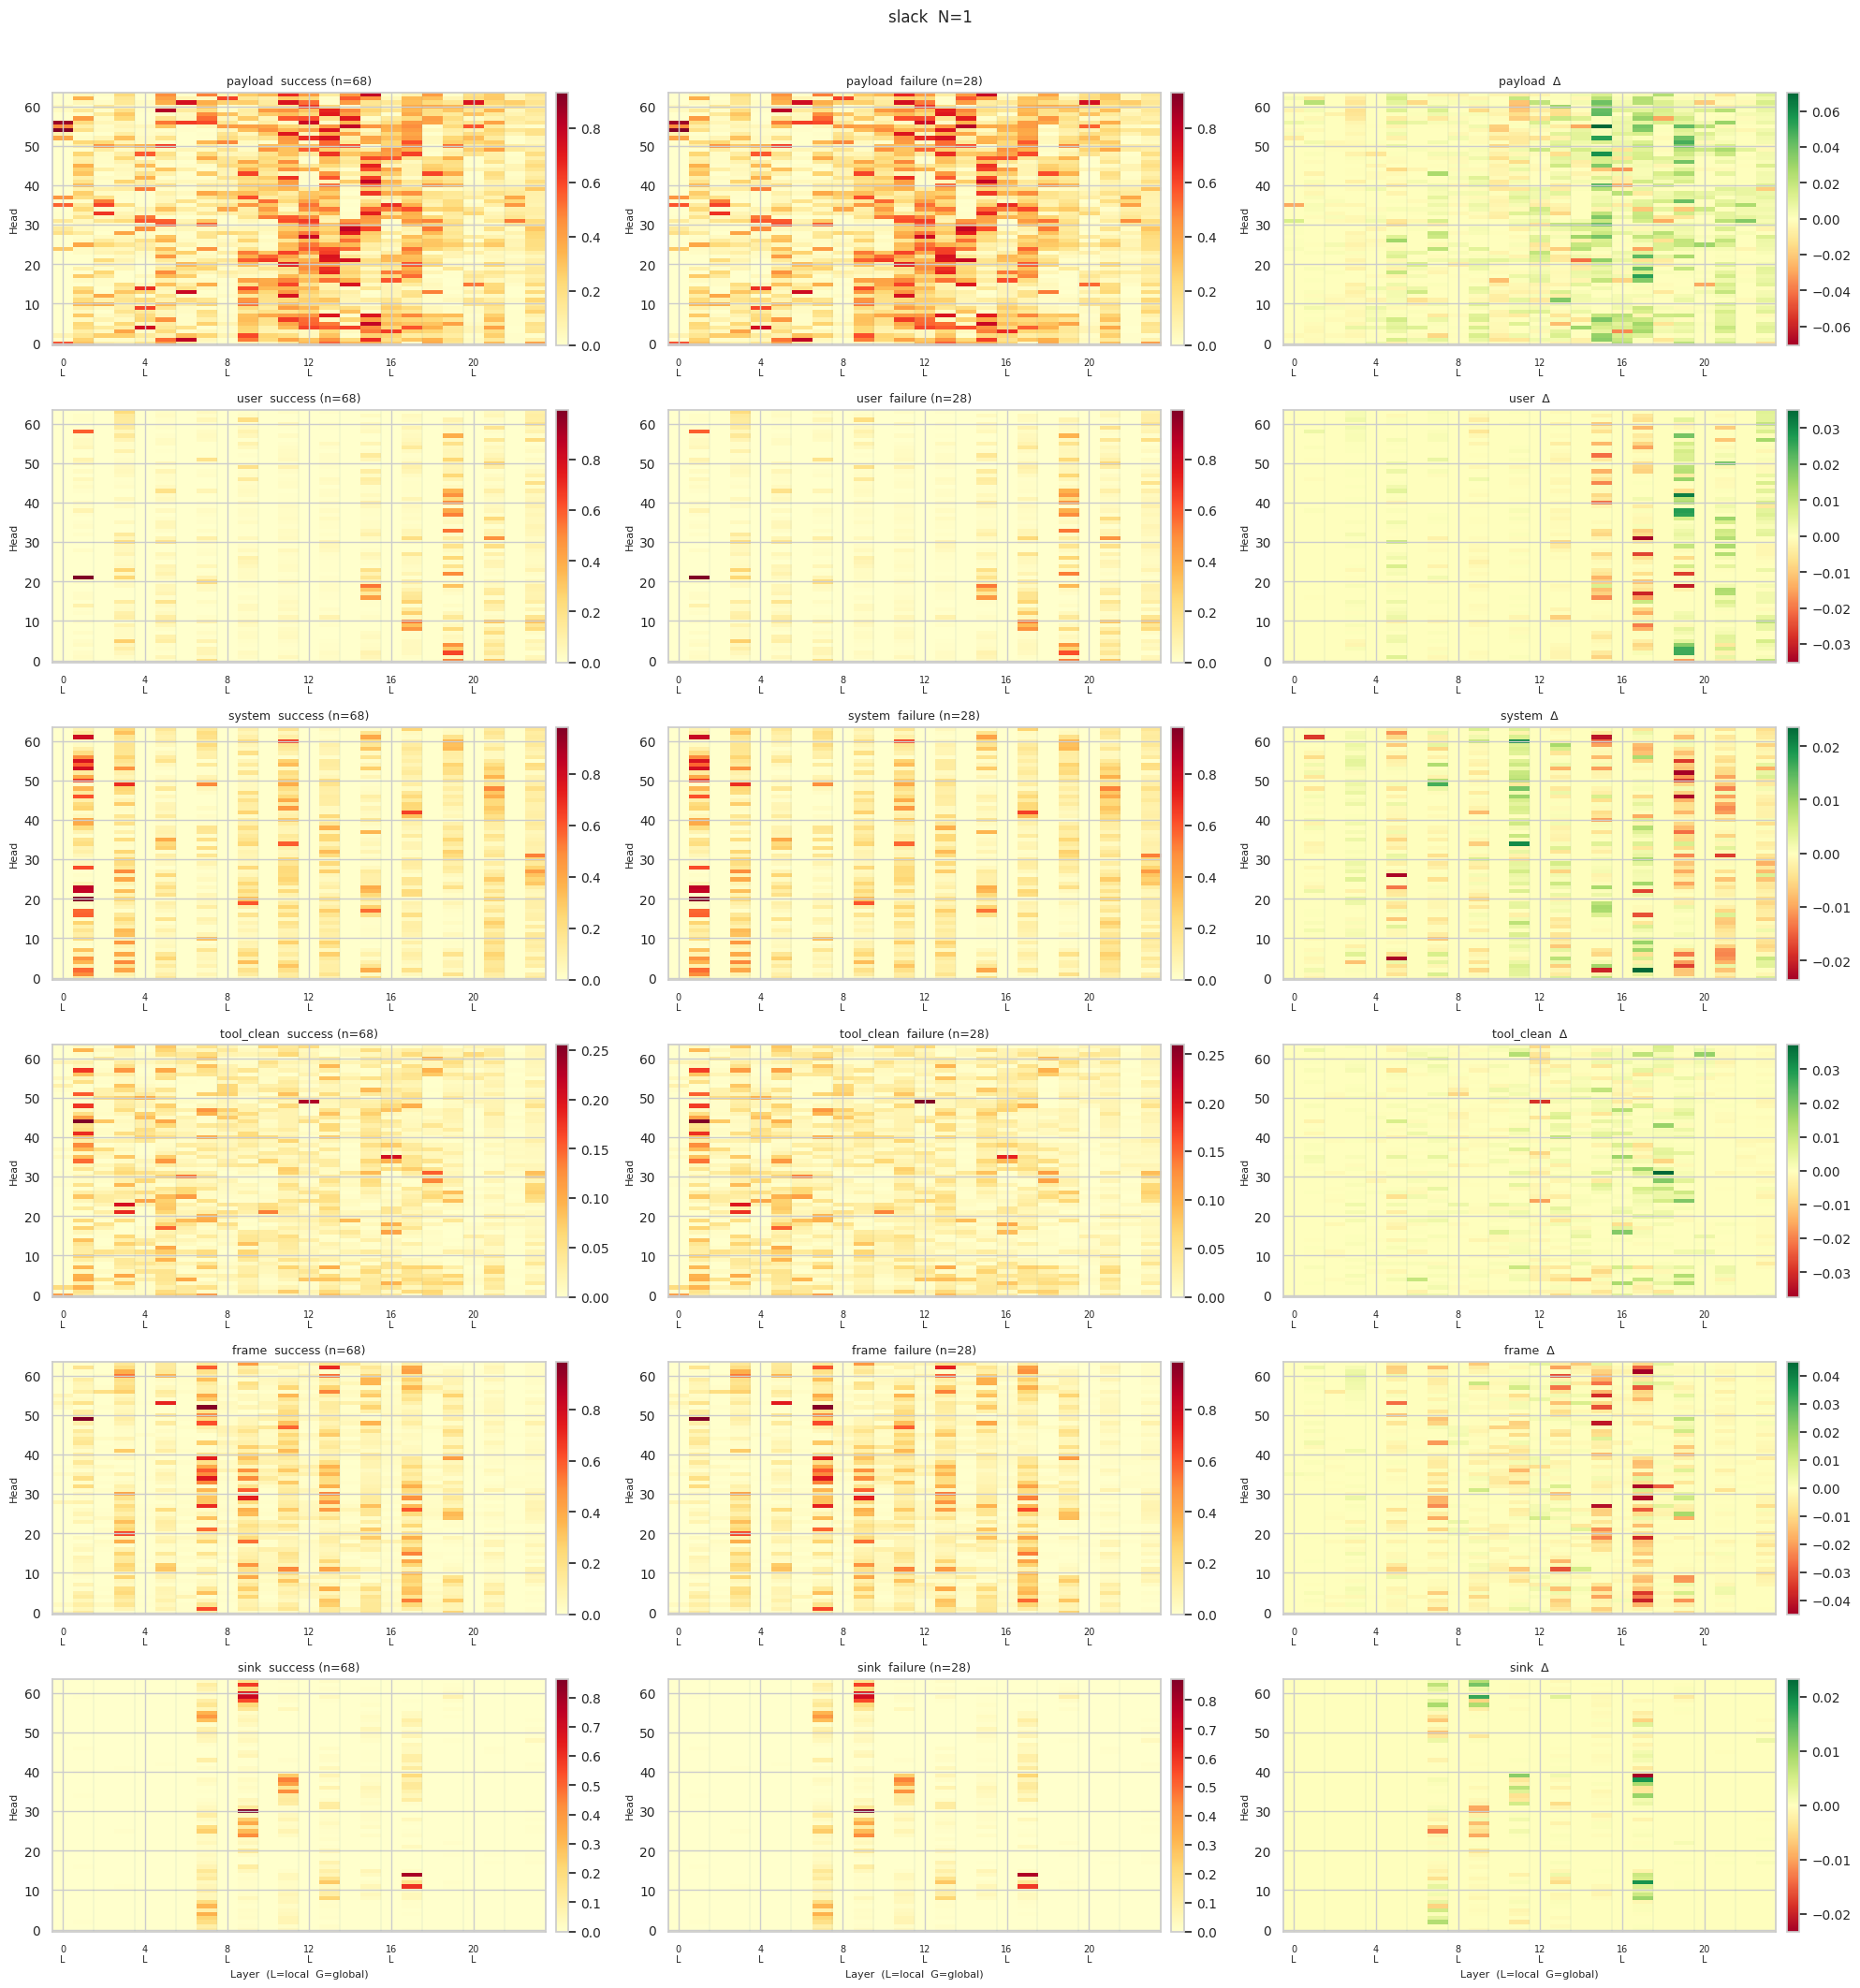

In [33]:
# slack  N=1  — all groups overview
mats = build_matrices('slack', N=1)
plot_layerhead_all_groups(mats, title='slack  N=1')

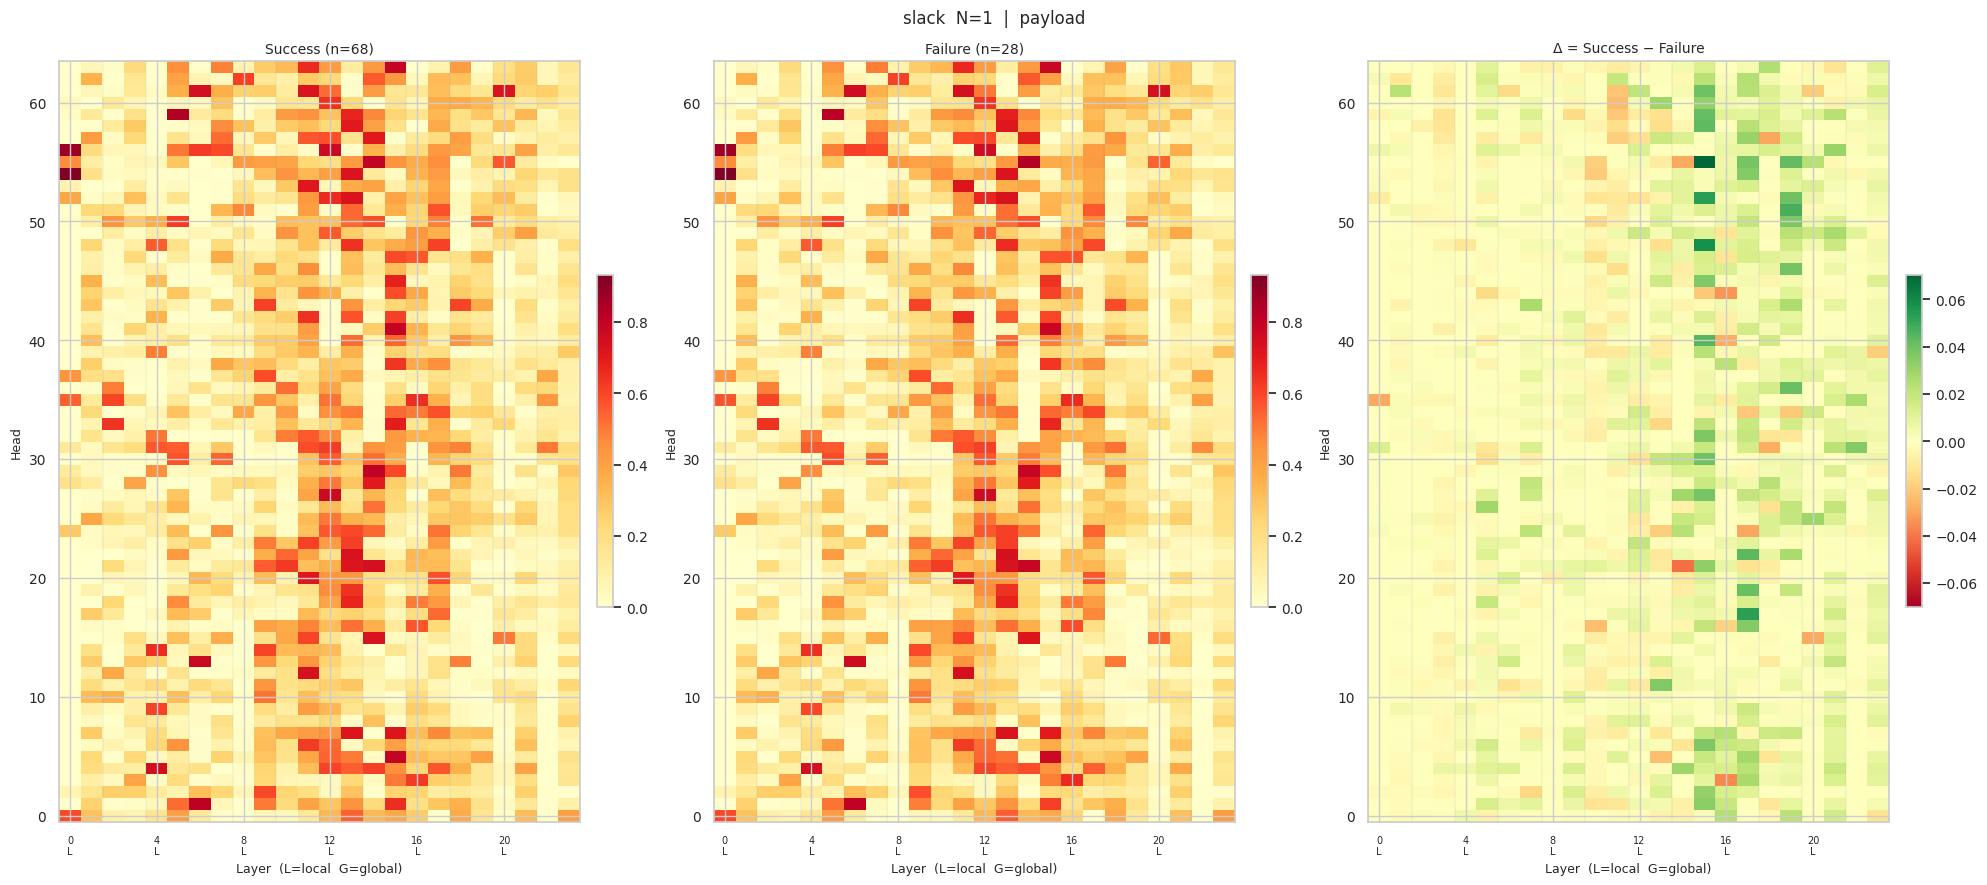

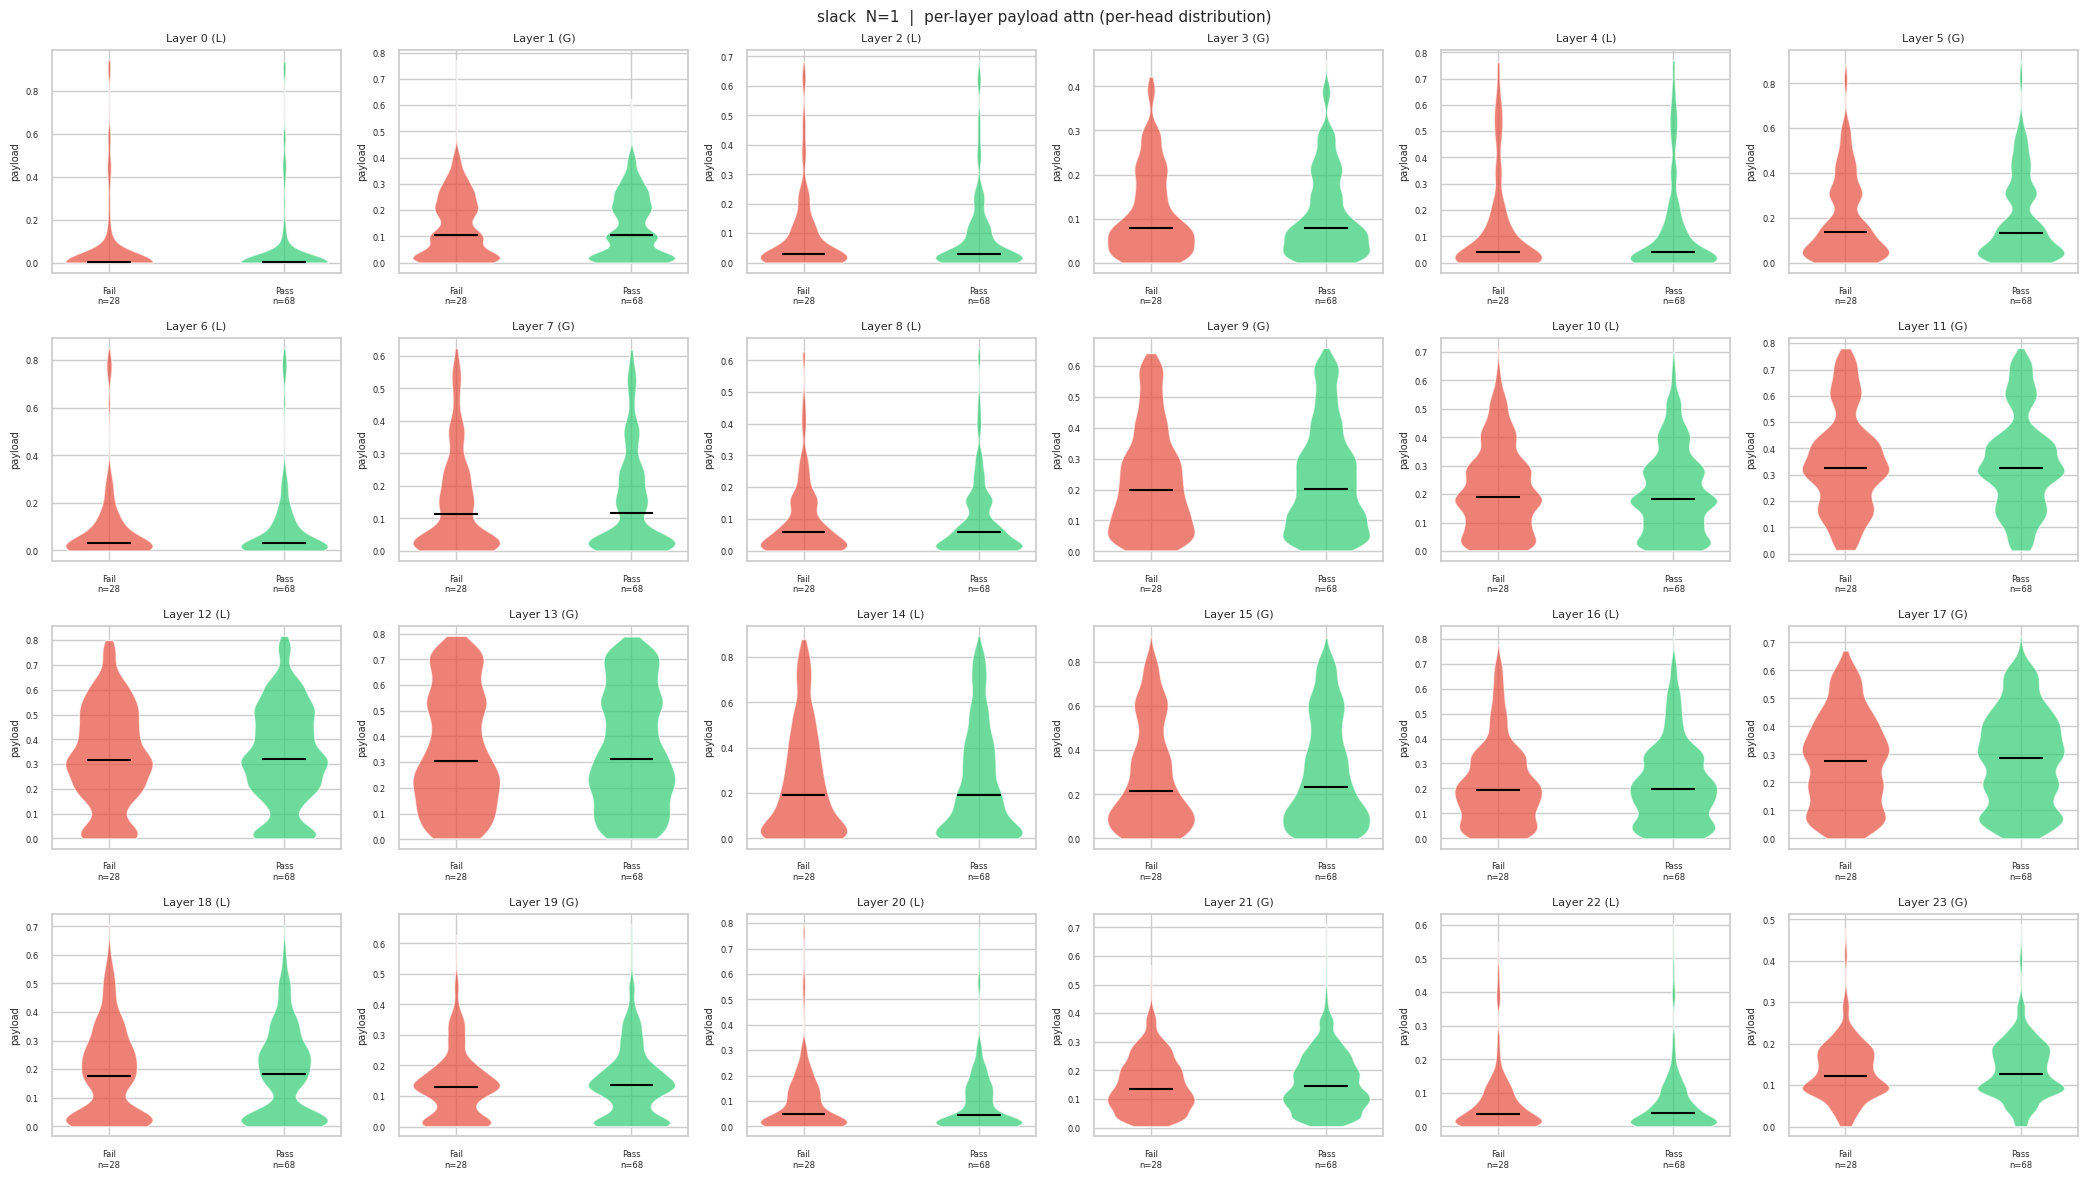

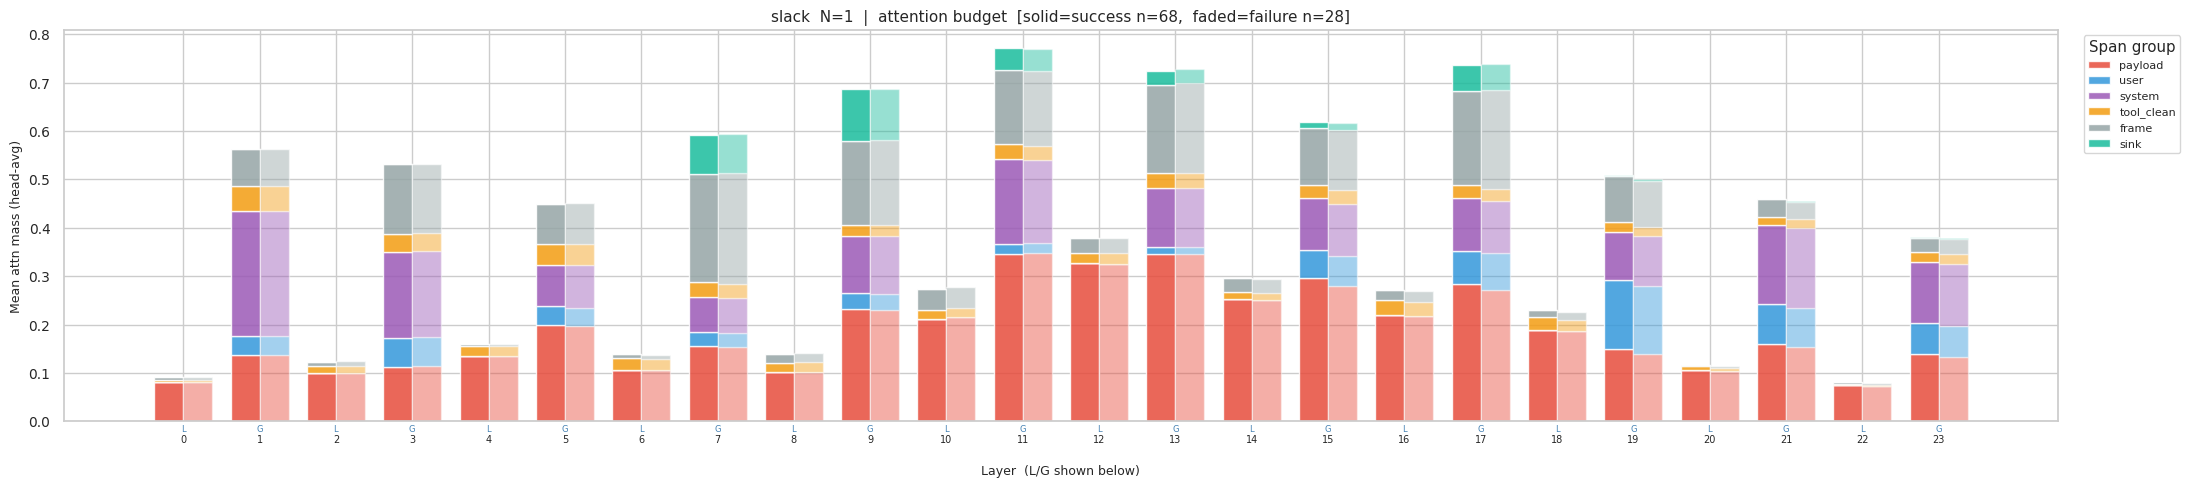

In [34]:
# slack  N=1  — payload deep-dive
mats = build_matrices('slack', N=1)
plot_layerhead(mats, group='payload', title='slack  N=1')
plot_violin_by_layer(mats, group='payload', title='slack  N=1')
plot_budget(mats, title='slack  N=1')

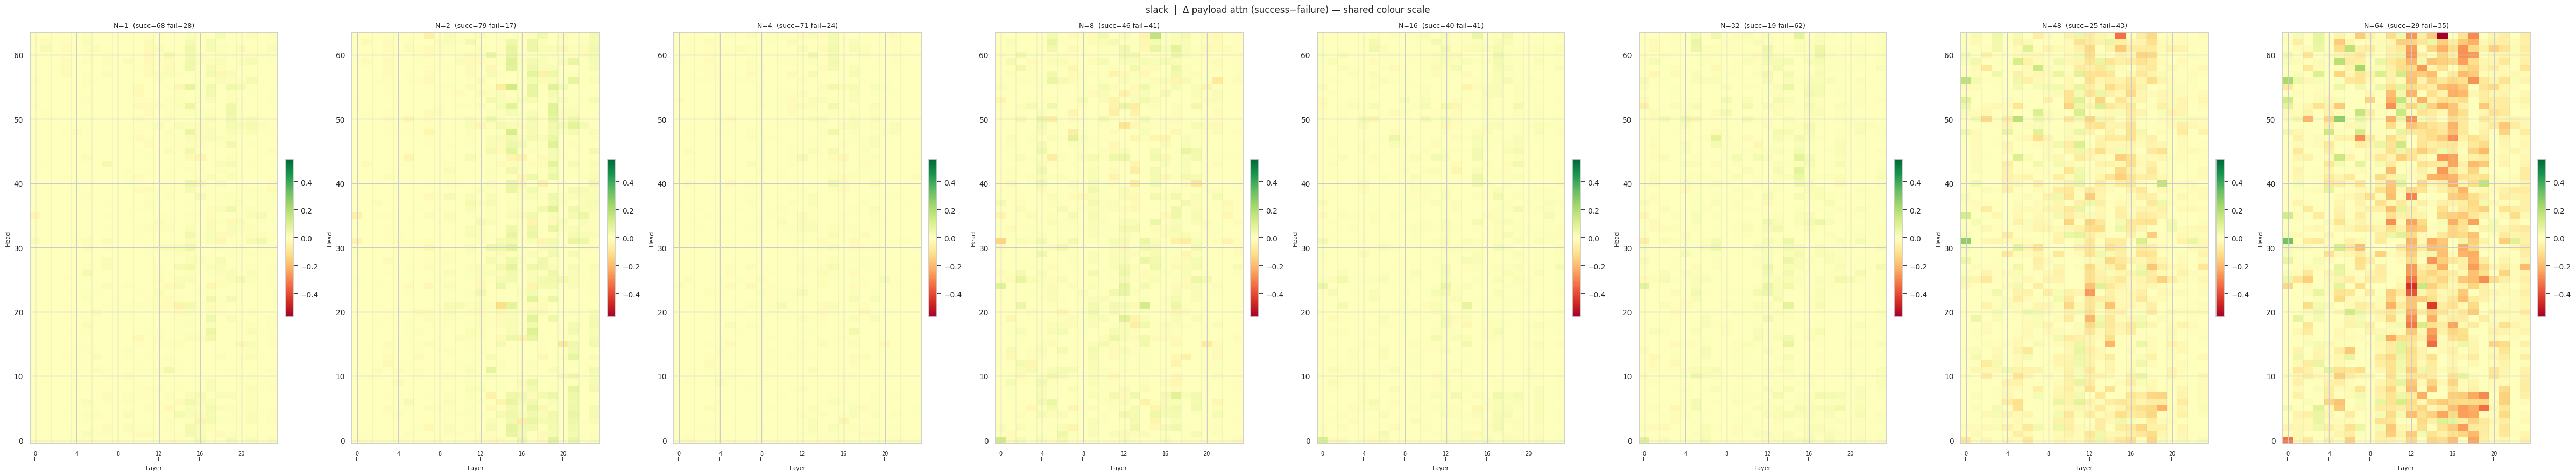

In [35]:
# slack  — payload Δ across all N values
plot_N_comparison('slack', group='payload')

In [36]:
# banking / travel — no captures in profiling_logs_v3
# Their runs completed but attention tensors were not saved.
# When new data arrives with captures for these examples, run:
#
#   mats = build_matrices('banking', N=1)
#   plot_layerhead_all_groups(mats, title='banking N=1')
#   plot_N_comparison('banking', group='payload')

for key in ['banking', 'travel']:
    ex = EXAMPLES[key]
    n_with_cap = sum(1 for r in ex['runs'] if r['run_id'] in cap_by_run)
    print(f'{key}: {len(ex["runs"])} runs,  {n_with_cap} with captures')

banking: 682 runs,  0 with captures
travel: 110 runs,  0 with captures


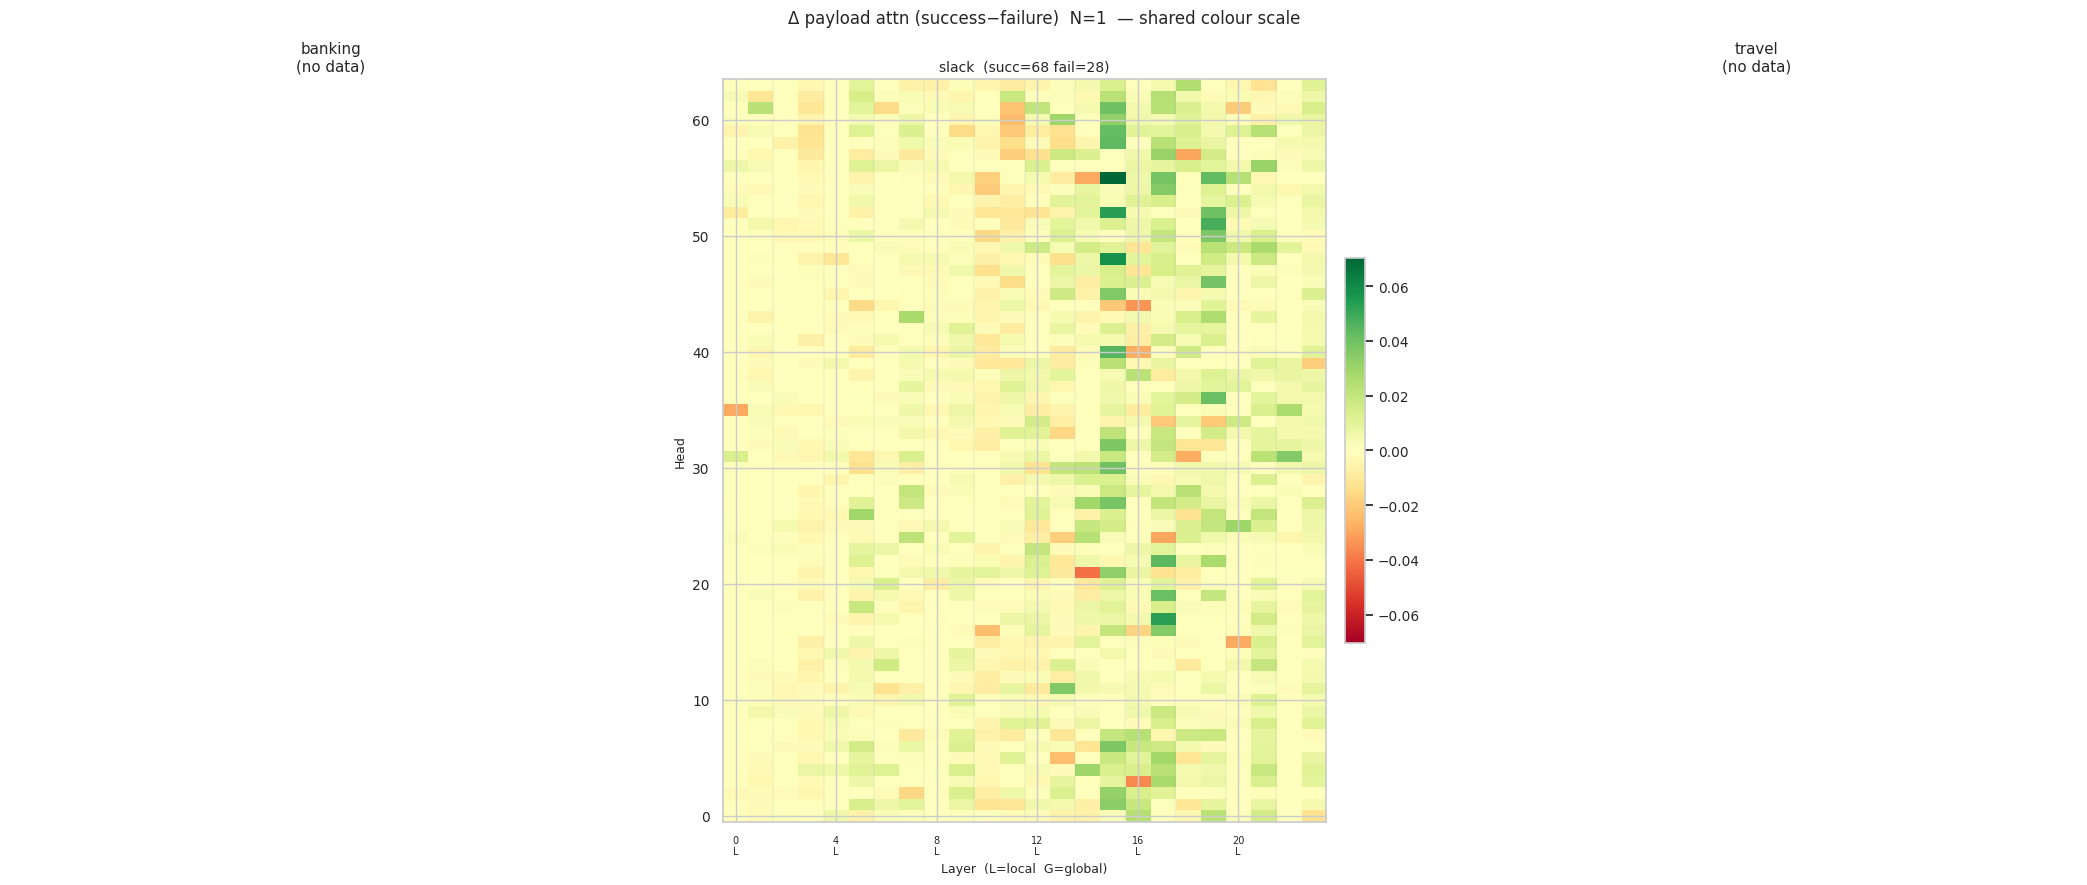

In [37]:
# Cross-example comparison — ready for when banking/travel captures arrive
# Currently only slack has captures, so this just shows one panel.
# Re-run once other examples have tensors.
plot_cross_example(N=1, group='payload')